# 06 — Hyperparameter tuning

Phase 6: `GridSearchCV` (`cv=5`, `scoring='roc_auc'`) on **X_train / y_train only**. Test data is used once, after `best_params_` are locked.

**Goal is not chasing AUC.** Phase 1–5 already showed a ~0.59 ceiling. The question is whether regularisation **closes the train/test gap** (RF 0.139, XGB 0.105, DT 0.483).

Script: `ml/tune.py`. **No `final_model.pkl`** (Phase 7).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "ml" / "tune.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.tune import COMPARISON_OUT, PARAMS_OUT, run_tuning

sns.set_theme(style="whitegrid")
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

if COMPARISON_OUT.exists():
    print("Loading existing Phase 6 artifacts (delete reports/tuned_model_comparison.csv to retune).")
    comparison = pd.read_csv(COMPARISON_OUT)
    best_params = json.loads(PARAMS_OUT.read_text(encoding="utf-8"))
else:
    out = run_tuning()
    comparison = out["comparison"]
    best_params = out["best_params"]

display(comparison.drop(columns=[c for c in comparison.columns if c == "best_params"]).round(4))
print("best_params_")
print(json.dumps(best_params, indent=2))

Loading existing Phase 6 artifacts (delete reports/tuned_model_comparison.csv to retune).


,model,accuracy,precision,recall,f1,roc_auc,train_roc_auc,roc_auc_gap,overfit_flag,cv_roc_auc,untuned_test_roc_auc,delta_vs_untuned,untuned_gap,gap_delta
0,XGBoost,0.5712,0.5610,0.4442,0.4958,0.5963,0.6093,0.0130,False,0.5952,0.5892,0.0071,0.1050,-0.0921
1,Random Forest,0.5705,0.5672,0.4012,0.4699,0.5938,0.6643,0.0706,True,0.5920,0.5940,-0.0002,0.1393,-0.0687
2,Logistic Regression,0.5669,0.5559,0.4349,0.4880,0.5898,0.5891,-0.0007,False,0.5886,0.5898,-0.0000,-0.0007,0.0000
3,Decision Tree,0.5579,0.5433,0.4296,0.4798,0.5770,0.6012,0.0242,False,0.5749,0.5173,0.0597,0.4827,-0.4586


best_params_
{
  "Logistic Regression": {
    "C": 10,
    "penalty": "l1"
  },
  "Decision Tree": {
    "max_depth": 8,
    "min_samples_leaf": 5
  },
  "Random Forest": {
    "max_depth": 10,
    "min_samples_leaf": 5,
    "n_estimators": 200
  },
  "XGBoost": {
    "learning_rate": 0.2,
    "max_depth": 3,
    "n_estimators": 100
  }
}


## 1. Best params and CV ROC-AUC

| Model | `best_params_` | CV ROC-AUC |
|-------|----------------|------------|
| Logistic Regression | `C=10`, `penalty='l1'`, `solver='liblinear'` | 0.589 |
| Decision Tree | `max_depth=8`, `min_samples_leaf=5` | 0.575 |
| Random Forest | `n_estimators=200`, `max_depth=10`, `min_samples_leaf=5` | 0.592 |
| XGBoost | `n_estimators=100`, `max_depth=3`, `learning_rate=0.2` | 0.595 |

CV chose **shallower / more regularised** trees (DT depth 8 not `None`; XGB depth 3, only 100 trees). RF stayed close to the Phase 4 default (depth 10 vs 12).

## 2. Test metrics vs untuned, and the overfit gap

,model,accuracy,precision,recall,f1,roc_auc,untuned_test_roc_auc,delta_vs_untuned,train_roc_auc,roc_auc_gap,untuned_gap,gap_delta,overfit_flag
0,XGBoost,0.5712,0.5610,0.4442,0.4958,0.5963,0.5892,0.0071,0.6093,0.0130,0.1050,-0.0921,False
1,Random Forest,0.5705,0.5672,0.4012,0.4699,0.5938,0.5940,-0.0002,0.6643,0.0706,0.1393,-0.0687,True
2,Logistic Regression,0.5669,0.5559,0.4349,0.4880,0.5898,0.5898,-0.0000,0.5891,-0.0007,-0.0007,0.0000,False
3,Decision Tree,0.5579,0.5433,0.4296,0.4798,0.5770,0.5173,0.0597,0.6012,0.0242,0.4827,-0.4586,False


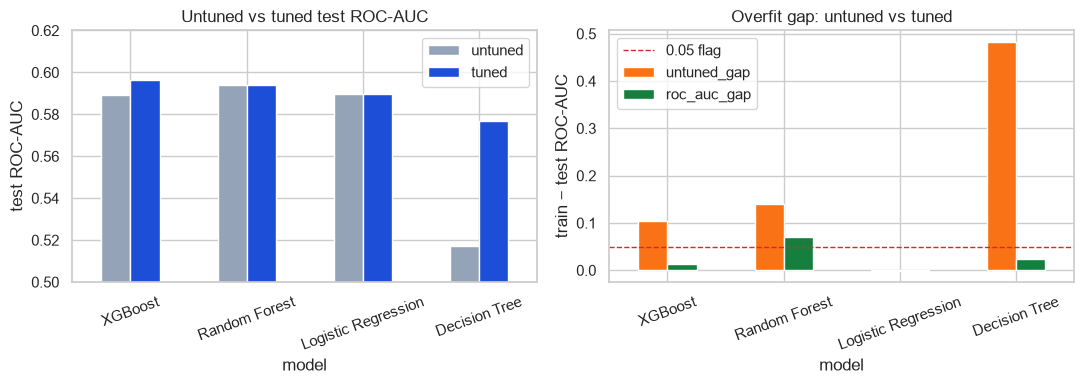

max |delta vs untuned AUC| = 0.0597


In [2]:
show = comparison[
    ["model", "accuracy", "precision", "recall", "f1", "roc_auc",
     "untuned_test_roc_auc", "delta_vs_untuned",
     "train_roc_auc", "roc_auc_gap", "untuned_gap", "gap_delta", "overfit_flag"]
]
display(show.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = comparison.sort_values("roc_auc", ascending=False)["model"]
plot = comparison.set_index("model").loc[order]

plot[["untuned_test_roc_auc", "roc_auc"]].plot(
    kind="bar", ax=axes[0], color=["#94a3b8", "#1d4ed8"], rot=20
)
axes[0].set_ylim(0.50, 0.62)
axes[0].set_ylabel("test ROC-AUC")
axes[0].set_title("Untuned vs tuned test ROC-AUC")
axes[0].legend(["untuned", "tuned"])

plot[["untuned_gap", "roc_auc_gap"]].plot(
    kind="bar", ax=axes[1], color=["#f97316", "#15803d"], rot=20
)
axes[1].axhline(0.05, color="#dc2626", ls="--", lw=1, label="0.05 flag")
axes[1].set_ylabel("train − test ROC-AUC")
axes[1].set_title("Overfit gap: untuned vs tuned")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / "15_tuning_auc_and_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print("max |delta vs untuned AUC| =", round(comparison["delta_vs_untuned"].abs().max(), 4))

## 3. Did tuning close the gap? Did AUC move?

| Model | Test AUC delta vs Phase 3/4 | Gap untuned → tuned | Gap closed? |
|-------|-----------------------------|---------------------|-------------|
| **XGBoost** | **+0.007** (0.589 → 0.596) | 0.105 → **0.013** | **Yes** (below 0.05) |
| Random Forest | **−0.000** (0.594 → 0.594) | 0.139 → **0.071** | Partially; **still flagged** |
| Logistic Regression | **0.000** | already ~0 | Already fine |
| Decision Tree | **+0.060** (0.517 → 0.577) | 0.483 → **0.024** | **Yes** (unpruned tree was the bug) |

**Plain finding:** tuning did **not** meaningfully raise test ROC-AUC for LR or RF. XGB’s +0.007 is small and still around the 0.59 plateau. DT’s +0.06 is real but it is **fixing a broken default**, not beating the ensembles.

RF’s gap **persists** (~0.07) even at the CV-best params (`max_depth=10`, `min_samples_leaf=5`). That points to a **feature-set / signal ceiling**, not only “we forgot to regularise.”

XGB CV picked a **weaker** model (depth 3, 100 trees) and that is what closed the gap — regularisation worked for boosting.

This is an **expected result** from Phases 1–5, not a failed search.

## 4. Still not a final-model pick

Phase 7 should weigh: remaining RF overfit vs XGB’s slightly higher test AUC and closed gap vs LR’s calibration and zero overfit. Do not use “highest ROC-AUC” alone.

Tuned pickles: `models/tuned_logistic_regression.pkl`, `tuned_decision_tree.pkl`, `tuned_random_forest.pkl`, `tuned_xgboost.pkl`.